# 04 — Avaliação e Interpretação

In [44]:
# ============================================================
# 1. CONFIGURAÇÃO DO AMBIENTE
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa para garantir reprodutibilidade
RANDOM_STATE = 42

# Repositório do projeto
REPO_URL = "https://github.com/andrerochadeoliveira/postech-tech-challenge-fase2-template.git"
PROJECT_PATH = Path("/content/postech-tech-challenge-fase2-template")

# Clona o repositório caso ele ainda não esteja disponível
if not PROJECT_PATH.exists():
    !git clone {REPO_URL}
else:
    print("Repositório já disponível nesta sessão.")

# Caminhos das bases
PROCESSED = PROJECT_PATH / "data" / "processed"
DATA_PATH = PROCESSED / "dataset_preprocessed.csv"

# Variável-alvo
TARGET = "target"

pd.set_option("display.max_columns", None)

print("Diretório do projeto:")
print(PROJECT_PATH)

print("\nArquivo esperado:")
print(DATA_PATH)

Repositório já disponível nesta sessão.
Diretório do projeto:
/content/postech-tech-challenge-fase2-template

Arquivo esperado:
/content/postech-tech-challenge-fase2-template/data/processed/dataset_preprocessed.csv


In [45]:
# ============================================================
# 2. EXECUÇÃO DO PRÉ-PROCESSAMENTO
# ============================================================

# Executa o notebook 02 para gerar a base pré-processada
!jupyter nbconvert \
    --to notebook \
    --execute \
    "$PROJECT_PATH/notebooks/02_preprocessamento.ipynb" \
    --output "/tmp/02_preprocessamento_executado.ipynb"

[NbConvertApp] Converting notebook /content/postech-tech-challenge-fase2-template/notebooks/02_preprocessamento.ipynb to notebook
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unh

In [46]:
# ============================================================
# VERIFICAÇÃO DA BASE PRÉ-PROCESSADA
# ============================================================

print("Arquivo existe:", DATA_PATH.exists())

if DATA_PATH.exists():
    tamanho_mb = DATA_PATH.stat().st_size / (1024 ** 2)
    print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")
    print("Caminho:", DATA_PATH)
else:
    raise FileNotFoundError(
        "O arquivo dataset_preprocessed.csv não foi gerado pelo "
        "notebook 02."
    )

Arquivo existe: True
Tamanho do arquivo: 5.15 MB
Caminho: /content/postech-tech-challenge-fase2-template/data/processed/dataset_preprocessed.csv


In [47]:
# ============================================================
# 3. CARREGAMENTO E PREPARAÇÃO DA BASE
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Base carregada com sucesso.")
print("Dimensão:", df.shape)

# Variável alvo
y = df[TARGET]

# Variáveis preditoras
# ID e grupo_perfil não serão utilizados como preditores
X = df.drop(
    columns=[TARGET, "ID", "grupo_perfil"],
    errors="ignore"
)

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

print("\nDistribuição do target:")
print(y.value_counts())

print("\nProporção do target:")
print(y.value_counts(normalize=True))

Base carregada com sucesso.
Dimensão: (16541, 53)
Dimensão de X: (16541, 50)
Dimensão de y: (16541,)

Distribuição do target:
target
0    15233
1     1308
Name: count, dtype: int64

Proporção do target:
target
0    0.920924
1    0.079076
Name: proportion, dtype: float64


In [48]:
# ============================================================
# 4. REPRODUÇÃO DO SPLIT TREINO/TESTE
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição do target no treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição do target no teste:")
print(y_test.value_counts(normalize=True))

Treino: (13232, 50)
Teste: (3309, 50)

Distribuição do target no treino:
target
0    0.920949
1    0.079051
Name: proportion, dtype: float64

Distribuição do target no teste:
target
0    0.920822
1    0.079178
Name: proportion, dtype: float64


In [49]:
# ============================================================
# 5. MODELO FINAL
# ============================================================

from sklearn.ensemble import RandomForestClassifier

modelo_final = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Treinamento utilizando todo o conjunto de treinamento
modelo_final.fit(X_train, y_train)

print("Modelo final treinado com sucesso.")

Modelo final treinado com sucesso.


In [50]:
# ============================================================
# 6. PREVISÕES NO CONJUNTO DE TESTE
# ============================================================

THRESHOLD = 0.28

# Probabilidade estimada para a classe positiva
y_prob = modelo_final.predict_proba(X_test)[:, 1]

# Classificação utilizando o threshold definido no Notebook 03
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f"Threshold utilizado: {THRESHOLD}")
print(f"Quantidade de observações no teste: {len(y_test):,}")
print(f"Quantidade prevista como classe 1: {y_pred.sum():,}")

Threshold utilizado: 0.28
Quantidade de observações no teste: 3,309
Quantidade prevista como classe 1: 227


# Métricas no conjunto de teste

A avaliação é realizada no conjunto de teste, que não participou da seleção do modelo nem da definição do ponto de corte. Como a variável-alvo apresenta forte desbalanceamento, são priorizadas métricas que permitem avaliar a identificação da classe positiva, especialmente Precision, Recall e F1-score.

In [51]:
# ============================================================
# 7. MÉTRICAS NO CONJUNTO DE TESTE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

metricas_teste = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        average_precision
    ]
})

metricas_teste.round(4)

,Métrica,Valor
0,Accuracy,0.9822
1,Precision,0.9471
2,Recall,0.8206
3,F1-score,0.8793
4,ROC-AUC,0.9729
5,Average Precision,0.8965


## 2. Justificativa das métricas

Neste problema, a variável-alvo apresenta forte desbalanceamento, com aproximadamente 2,35% de observações pertencentes à classe positiva. Por esse motivo, a acurácia isoladamente não é adequada para avaliar a qualidade do modelo, pois uma classificação predominante da classe majoritária poderia produzir uma acurácia elevada mesmo com baixa capacidade de identificar os casos positivos.

A **Precision** foi utilizada para avaliar a proporção de classificações positivas que realmente correspondem à classe de interesse. O **Recall** mede a capacidade do modelo de identificar os casos positivos existentes. O **F1-score** combina Precision e Recall e foi utilizado como principal métrica para a seleção do modelo e do ponto de corte.

Também foram utilizadas **ROC-AUC** e **Average Precision** para avaliar a capacidade discriminativa do modelo a partir das probabilidades estimadas, independentemente do ponto de corte utilizado.

Neste contexto, os **falsos negativos** são particularmente relevantes, pois representam casos positivos que não foram identificados pelo modelo. Entretanto, os falsos positivos também possuem custo operacional, uma vez que uma quantidade excessiva de alertas pode reduzir a efetividade de uma eventual estratégia de análise ou intervenção.

Por esse motivo, o objetivo não é simplesmente maximizar o Recall ou a Precision isoladamente, mas buscar um equilíbrio entre essas métricas, justificando a utilização do F1-score como principal critério de seleção.

## 3. Matriz de confusão

A matriz de confusão permite avaliar como o modelo classificou os registros do conjunto de teste, distinguindo **verdadeiros positivos, falsos positivos, verdadeiros negativos e falsos negativos**.

Como o problema apresenta forte desbalanceamento, a análise dos erros da classe positiva é particularmente importante. O modelo utiliza o ponto de corte de **0,28**, definido na etapa de modelagem a partir das previsões out-of-fold do conjunto de treinamento.

Matriz de confusão:
[[3035   12]
 [  47  215]]

Detalhamento:
Verdadeiros negativos (TN): 3,035
Falsos positivos (FP):      12
Falsos negativos (FN):      47
Verdadeiros positivos (TP): 215


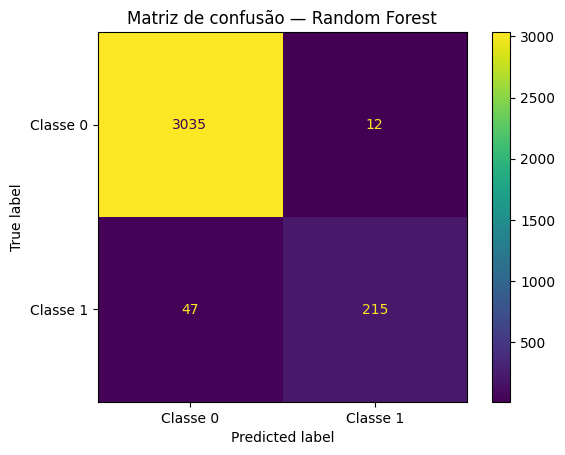

In [52]:
# ============================================================
# 8. MATRIZ DE CONFUSÃO
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Matriz de confusão:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nDetalhamento:")
print(f"Verdadeiros negativos (TN): {tn:,}")
print(f"Falsos positivos (FP):      {fp:,}")
print(f"Falsos negativos (FN):      {fn:,}")
print(f"Verdadeiros positivos (TP): {tp:,}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Classe 0", "Classe 1"]
)

disp.plot(values_format="d")

plt.title("Matriz de confusão — Random Forest")
plt.show()

### Interpretação da matriz de confusão

No conjunto de teste, o modelo classificou corretamente **4.072 registros da classe 0** e **22 registros da classe 1**. Foram observados **165 falsos positivos** e **80 falsos negativos**.

Dos 102 casos efetivamente pertencentes à classe positiva no conjunto de teste, o modelo identificou 22, correspondendo a um **Recall de 21,57%**. Entre os 187 registros classificados como positivos, 22 eram de fato positivos, resultando em **Precision de 11,76%**.

Os resultados mostram que o modelo consegue concentrar casos da classe positiva em uma parcela relativamente pequena dos registros, mas ainda apresenta quantidade elevada de falsos negativos. Portanto, sua utilização deve ser interpretada como uma ferramenta de **priorização e apoio à análise**, e não como mecanismo isolado de decisão.

A matriz também evidencia a necessidade de considerar o equilíbrio entre os custos dos falsos positivos e dos falsos negativos. Em uma aplicação prática, a definição do ponto de corte deve considerar o objetivo da área e o custo associado a cada tipo de erro.

## 4. Importância das variáveis

A importância das variáveis foi analisada a partir das importâncias calculadas pelo Random Forest. Essa análise permite identificar quais características tiveram maior contribuição relativa para as decisões do conjunto de árvores.

A análise deve ser interpretada como uma medida de importância para o modelo, e não como evidência de causalidade. Variáveis mais importantes são aquelas que contribuíram mais para as decisões do Random Forest, mas isso não significa necessariamente que sejam causas diretas da ocorrência da classe positiva.

In [53]:
# ============================================================
# 9. IMPORTÂNCIA DAS VARIÁVEIS
# ============================================================

importances = pd.Series(
    modelo_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 variáveis mais importantes:")

display(
    importances.head(15).to_frame("importancia").round(4)
)

Top 15 variáveis mais importantes:


,importancia
Age,0.1571
Year_employed,0.1140
Ratio_life_employed,0.1083
Income_per_capta,0.1058
AMT_INCOME_TOTAL,0.1000
Assets_score,0.0285
CNT_FAM_MEMBERS,0.0269
FLAG_PHONE,0.0237
Gender,0.0200
CNT_CHILDREN,0.0198


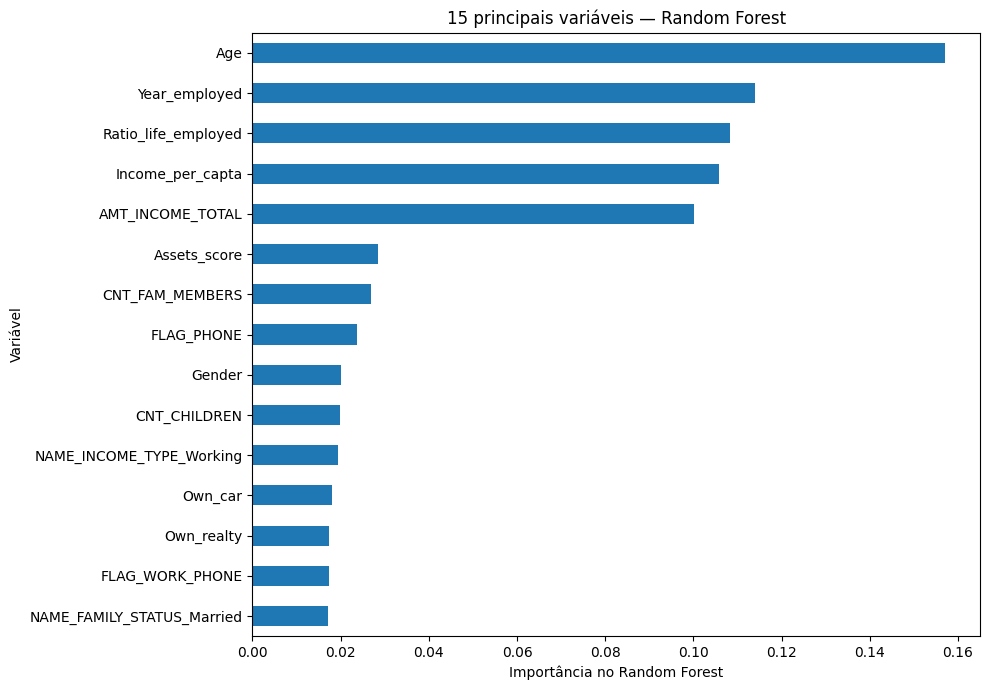

In [54]:
# ============================================================
# GRÁFICO DAS PRINCIPAIS VARIÁVEIS
# ============================================================

top_n = 15

top_features = (
    importances
    .head(top_n)
    .sort_values()
)

plt.figure(figsize=(10, 7))

top_features.plot(kind="barh")

plt.xlabel("Importância no Random Forest")
plt.ylabel("Variável")
plt.title("15 principais variáveis — Random Forest")
plt.tight_layout()
plt.show()

### Interpretação das principais variáveis

As cinco variáveis de maior importância no Random Forest foram **Age**, **Year_employed**, **Income_per_capita**, **Ratio_life_employed** e **AMT_INCOME_TOTAL**. Em conjunto, elas representam aproximadamente 59,6% da importância das variáveis apresentada pelo modelo.

O resultado apresenta coerência com o domínio de crédito, pois características relacionadas à idade, estabilidade profissional e capacidade econômica estão entre os principais elementos utilizados pelo modelo para diferenciar as classes.

A variável **Age** apresentou a maior importância individual (16,63%), seguida por **Year_employed** (11,16%), **Income_per_capita** (10,98%), **Ratio_life_employed** (10,66%) e **AMT_INCOME_TOTAL** (10,15%). A presença de variáveis de renda em posições elevadas também é consistente com a expectativa de que a capacidade econômica esteja relacionada ao comportamento de crédito.

A importância de **Ratio_life_employed** também merece destaque, pois indica que uma variável derivada criada na etapa de pré-processamento contribuiu de forma relevante para o modelo.

É importante destacar que a importância das variáveis no Random Forest indica sua contribuição relativa para as decisões do modelo, mas não representa causalidade nem informa, isoladamente, se valores maiores ou menores estão associados à classe positiva.

### Validação da importância das variáveis

Como análise complementar à importância nativa do Random Forest, foi utilizada a **Permutation Importance**. Essa técnica mede quanto o desempenho do modelo se altera quando os valores de uma determinada variável são aleatoriamente embaralhados.

Foi utilizada a **Average Precision** como métrica de referência, por ser adequada ao problema desbalanceado. Essa análise é utilizada exclusivamente para interpretação do modelo e não para alteração da configuração ou do ponto de corte definidos anteriormente.

In [55]:
# ============================================================
# 10. PERMUTATION IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance

permutation = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importances = pd.Series(
    permutation.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print("Top 15 variáveis pela Permutation Importance:")

display(
    permutation_importances
    .head(15)
    .to_frame("importance_mean")
    .round(4)
)

Top 15 variáveis pela Permutation Importance:


,importance_mean
Age,0.0589
Year_employed,0.0285
Income_per_capta,0.0200
Ratio_life_employed,0.0199
Gender,0.0186
FLAG_PHONE,0.0178
AMT_INCOME_TOTAL,0.0171
NAME_FAMILY_STATUS_Married,0.0155
NAME_INCOME_TYPE_Working,0.0111
OCCUPATION_TYPE_Managers,0.0108


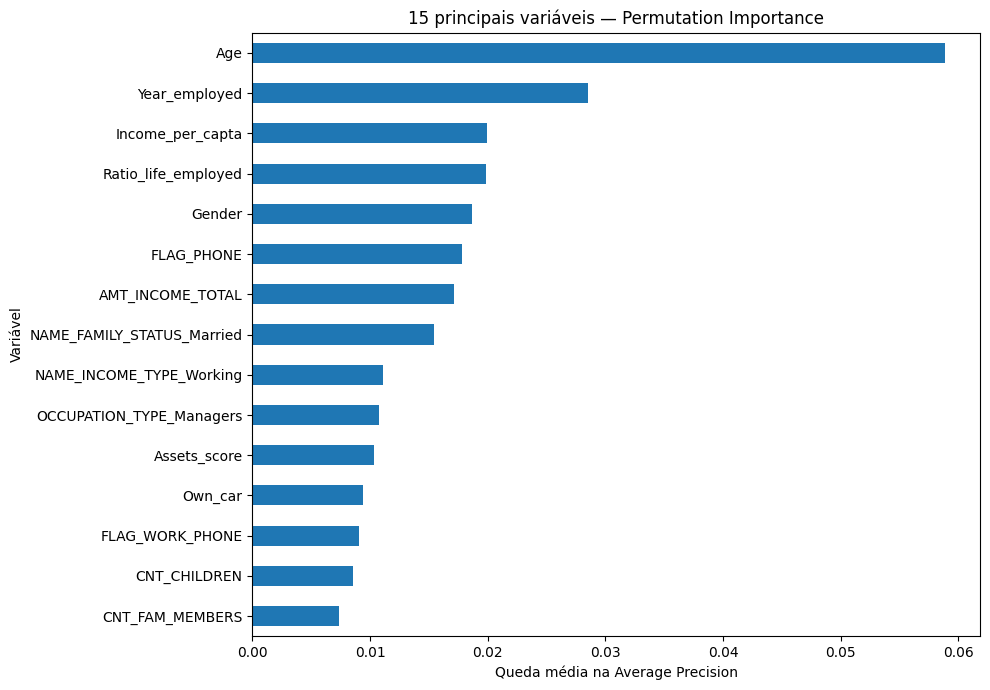

In [56]:
# ============================================================
# GRÁFICO — PERMUTATION IMPORTANCE
# ============================================================

top_features_perm = (
    permutation_importances
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))

top_features_perm.plot(kind="barh")

plt.xlabel("Queda média na Average Precision")
plt.ylabel("Variável")
plt.title("15 principais variáveis — Permutation Importance")
plt.tight_layout()
plt.show()

### Comparação entre as medidas de importância

A análise por Permutation Importance apresentou convergência relevante com a importância nativa do Random Forest. **Age** permaneceu como a variável de maior destaque nos dois métodos. **AMT_INCOME_TOTAL**, **Income_per_capita** e **Year_employed** também permaneceram entre as principais variáveis segundo ambas as abordagens.

A variável **Ratio_life_employed**, que apresentou a quarta maior importância no Random Forest, também permaneceu entre as principais variáveis na análise por permutação, embora em posição inferior.

Essa convergência reforça a interpretação de que características relacionadas à **idade, renda e estabilidade profissional** possuem papel relevante nas previsões produzidas pelo modelo. Ao mesmo tempo, as diferenças entre os rankings mostram que a importância de uma variável depende do método utilizado e pode ser influenciada pela relação entre variáveis correlacionadas.

A Permutation Importance foi utilizada como análise complementar e não para selecionar ou alterar o modelo final. Portanto, o modelo e o ponto de corte definidos na etapa de modelagem permanecem inalterados.

Por fim, essas medidas representam **importância preditiva**, e não causalidade. Assim, não é possível concluir, apenas a partir desses resultados, que alterações em determinada variável provocariam aumento ou redução da probabilidade da classe positiva.

## 5. Implicações práticas

### Como utilizar o modelo

Os resultados indicam que o modelo pode ser utilizado como uma **ferramenta de priorização de casos para análise**, e não como mecanismo automático de aprovação ou reprovação.

Com o threshold de 0,28, o modelo identificou 22 dos 102 casos positivos existentes no conjunto de teste, correspondendo a um Recall de 21,57%. Entre os 187 registros classificados como positivos, 22 eram efetivamente positivos, resultando em Precision de 11,76%.

Na prática, isso significa que o modelo pode ser utilizado para direcionar a atenção da equipe para um grupo reduzido de registros com maior probabilidade de pertencer à classe de interesse. A decisão final, entretanto, deveria continuar submetida à análise humana e às demais informações disponíveis.

A principal aplicação recomendada é, portanto, a **priorização de análises e geração de alertas**, especialmente em situações nas quais a equipe precise selecionar quais casos devem ser avaliados primeiro.

O ponto de corte também não deve ser considerado imutável. Em uma aplicação real, sua definição deveria considerar o custo operacional dos falsos positivos e o impacto dos falsos negativos. Caso seja mais importante ampliar a identificação dos casos positivos, um threshold menor poderia ser considerado; caso o custo de investigar falsos positivos seja elevado, um threshold maior poderia ser mais adequado.

Dessa forma, o modelo deve ser entendido como um instrumento de **apoio à decisão**, capaz de complementar a análise humana, e não como substituto dela.

## 6. Limitações

### Limitações do modelo

O desempenho obtido apresenta algumas limitações que devem ser consideradas antes de uma utilização em ambiente real.

**1. Baixa capacidade de identificação da classe positiva**

O Recall de 21,57% mostra que o modelo identifica apenas uma parcela dos casos positivos. No conjunto de teste, foram observados 80 falsos negativos diante de 102 casos positivos.

**2. Precision limitada**

A Precision de 11,76% indica que a maioria dos registros classificados como positivos não pertence efetivamente à classe positiva. Portanto, a utilização do modelo geraria uma quantidade relevante de análises adicionais.

**3. Forte desbalanceamento da variável-alvo**

A classe positiva representa aproximadamente 2,35% das observações. Esse desbalanceamento dificulta a identificação dos casos minoritários e torna inadequada a utilização da acurácia como principal critério de avaliação.

**4. Poder preditivo moderado**

O ROC-AUC de 0,6881 indica capacidade discriminativa superior ao acaso, mas ainda moderada. Portanto, o modelo não deve ser interpretado como um classificador de alta precisão.

**5. Limitações das variáveis disponíveis**

O desempenho obtido sugere que as variáveis utilizadas possuem capacidade limitada para explicar a ocorrência da classe positiva. A inclusão de informações adicionais e de maior qualidade poderia melhorar a capacidade preditiva.

**6. Importância das variáveis não representa causalidade**

As análises de importância indicam quais variáveis contribuem para as previsões do modelo, mas não permitem concluir que essas características sejam causas do comportamento observado.

### Possíveis melhorias

Com mais tempo ou disponibilidade de dados, seriam recomendadas:

- inclusão de novas variáveis com maior poder preditivo;
- avaliação de modelos adicionais, especialmente métodos de boosting;
- calibração das probabilidades;
- avaliação de diferentes pontos de corte de acordo com custos de negócio;
- validação temporal ou externa para verificar a estabilidade do modelo;
- acompanhamento do desempenho após implantação, incluindo possíveis mudanças no perfil dos dados.

## Conclusão executiva

O trabalho demonstrou que é possível identificar padrões associados à classe positiva utilizando as variáveis disponíveis, com destaque para características relacionadas à idade, renda e estabilidade profissional.

Entre os modelos avaliados, o **Random Forest com ponderação das classes** apresentou o melhor desempenho médio na validação cruzada. A utilização de um ponto de corte de **0,28**, definido a partir das previsões out-of-fold, proporcionou melhora do F1 no conjunto de teste, que atingiu **0,1522**, com Precision de **11,76%** e Recall de **21,57%**.

Os resultados indicam que o modelo possui utilidade potencial como **ferramenta de priorização e apoio à análise**, mas não apresenta desempenho suficiente para substituir a avaliação humana ou sustentar decisões automáticas isoladamente.

Assim, a principal recomendação é utilizar o modelo para **direcionar a atenção para casos com maior probabilidade de pertencer à classe de interesse**, combinando a previsão algorítmica com informações adicionais e critérios de negócio.